### Import the Necessary Packages

In this section, we import the necessary Python libraries for data processing, model building, and evaluation.

#### Core Libraries
- `pandas`: Data manipulation and analysis
- `numpy`: Numerical computations

#### Machine Learning Models (Scikit-learn)
- `LinearRegression`: Basic linear model
- `Ridge`: Linear regression with L2 regularization
- `Lasso`: Linear regression with L1 regularization
- `RandomForestRegressor`: Ensemble tree-based model
- `GradientBoostingRegressor`: Boosting-based ensemble model

#### Model Evaluation Metrics
- `mean_squared_error`: Measures prediction error
- `r2_score`: Explains variance captured by the model

#### Data Splitting
- `train_test_split`: Splits dataset into training and testing sets

#### Visualization
- `matplotlib.pyplot`: Used for plotting results and analysis

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

### Load the Data

We load the dataset using `pandas.read_csv()` and store it in a DataFrame called `df`.

This dataset (`insurance.csv`) contains information about individuals and their medical insurance costs. It will be used to build a machine learning model to predict insurance charges based on personal and health-related features.

Each row represents an individual, and each column represents a feature used for prediction:

- **age**: Age of the primary beneficiary.
- **sex**: Gender of the policyholder (female or male).
- **bmi**: Body Mass Index (BMI), calculated as weight (kg) / height² (m²).  
  This indicates whether a person is underweight, normal weight, or overweight.  
  A typical healthy range is 18.5 to 24.9.
- **children**: Number of dependents covered by the insurance plan.
- **smoker**: Indicates whether the individual is a smoker (yes or no).
- **region**: Residential area in the U.S. (northeast, southeast, southwest, northwest).
- **charges**: Medical costs billed by health insurance (target variable to be predicted).

More documentation: https://www.kaggle.com/datasets/mirichoi0218/insurance?select=insurance.csv

In [29]:
df = pd.read_csv("insurance.csv")

### Basic Exploration

In this section, we perform an initial exploration of the dataset to understand its structure and key patterns.

We begin by checking for missing values, viewing sample rows, and reviewing dataset dimensions. We also generate summary statistics to understand the distribution of numerical variables.

Additionally, we analyze how insurance charges vary across important features:
- Smoking status
- Age
- Number of children (dependents)

These comparisons help identify which variables have the strongest relationship with medical insurance costs, which is important for building an accurate predictive model.

In [4]:
print(f"\n--- CHECK FOR NULL ---\n{df.isnull().sum()}")
print(f"\n--- HEAD ---\n{df.head()}")
print(f"\n--- SHAPE ---\n{df.shape}")
print(f"\n--- DESCRIPTION ---\n{df.describe()}")

print("\n--- MEAN BY SMOKER ---")
print(df.groupby('smoker')['charges'].mean())

print("\n--- MEAN BY AGE ---")
print(df.groupby('age')['charges'].mean())

print("\n--- MEAN BY CHILDREN ---")
print(df.groupby('children')['charges'].mean())


--- CHECK FOR NULL ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- HEAD ---
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

--- SHAPE ---
(1338, 7)

--- DESCRIPTION ---
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%     

### Risk Segmentation

In this section, we create categorical age groups using `pd.cut()` to simplify analysis of age-related trends.

We then group the dataset by:
- Age group
- Smoking status

For each combination, we compute:
- **Mean**: average insurance charges
- **Standard deviation**: variability of charges within the group
- **Count**: number of records in each group

This helps us understand how smoking behavior and age together impact insurance costs, which is useful for identifying high-risk populations.

In [5]:
df["age_group"] = pd.cut(df["age"], bins=[17, 30, 45, 60, 100])

grouped = df.groupby(["age_group", "smoker"], observed=True)["charges"].agg(["mean", "std", "count"])
print(f"\n--- GROUPED BY AGE & SMOKER ---\n{grouped}")


--- GROUPED BY AGE & SMOKER ---
                          mean           std  count
age_group smoker                                   
(17, 30]  no       4462.308505   5185.194597    349
          yes     27528.078343  10309.676415     95
(30, 45]  no       7246.170138   3943.699827    307
          yes     31707.164316  11442.496547     87
(45, 60]  no      12188.334036   5034.483173    339
          yes     36451.732069  11296.863132     70
(60, 100] no      15366.613482   4654.813140     69
          yes     38929.615407   9656.866051     22


### Model Building

In this section, we prepare the dataset for machine learning and train multiple regression models.

#### Data Preparation
- One-hot encoding is applied using `pd.get_dummies()` to convert categorical variables into numerical format.  
- The `drop_first=True` option is used to avoid multicollinearity.  
- The dataset is split into:
  - **Features (X)**: independent variables  
  - **Target (y)**: insurance charges  
- An 80/20 train-test split is used.

#### Model Training
We train and compare multiple regression models:

- Linear Regression  
- Ridge Regression  
- Lasso Regression  
- Random Forest Regressor  
- Gradient Boosting Regressor  

All models are trained on the training set and stored for later evaluation.

In [15]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================
# MODEL TRAINING
# =========================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

### Model Evaluation

In this section, we evaluate the performance of all trained models using common regression metrics and compare their results.

#### Evaluation Metrics
- **RMSE (Root Mean Squared Error)**: Measures the average prediction error in the same units as insurance charges. Lower values indicate better performance.
- **R² Score**: Measures how well the model explains variance in the target variable. Values closer to 1 indicate a better fit.


#### Model Evaluation Process
- Each trained model generates predictions on the test set.
- RMSE and R² scores are calculated for each model.
- Results are stored and displayed for comparison.


#### Model Ranking
- Models are sorted by RMSE (lowest to highest).
- The model with the lowest RMSE is selected as the best model.


#### R² Score Interpretation
- **Above 0.7** → Good fit  
- **0.5 to 0.7** → Moderate fit  
- **Below 0.5** → Weak fit  


#### Final Output
- The best-performing model is selected based on RMSE.
- Predictions are generated using the best model on the test set.

In [16]:
# =========================
# MODEL EVALUATION
# =========================
results = []

print("\n--- MODEL PERFORMANCE COMPARISON ---")

for name, model in trained_models.items():
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append((name, model, rmse, r2))
    
    print(f"\n{name}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R² Score: {r2:.4f}")

# Sort by best RMSE
results = sorted(results, key=lambda x: x[2])

print("\n--- BEST MODEL RANKING (by RMSE) ---")
for rank, (name, _, rmse, r2) in enumerate(results, 1):
    print(f"{rank}. {name} | RMSE: ${rmse:,.2f} | R²: {r2:.4f}")

# Select best model
best_name, best_model, best_rmse, best_r2 = results[0]

print(f"\n✅ Best Model Selected: {best_name}")


# =========================
# FINAL PREDICTIONS (BEST MODEL)
# =========================
best_preds = best_model.predict(X_test)


--- MODEL PERFORMANCE COMPARISON ---

Linear Regression
RMSE: $5,793.02
R² Score: 0.7838

Ridge
RMSE: $5,796.50
R² Score: 0.7836

Lasso
RMSE: $5,793.02
R² Score: 0.7838

Random Forest
RMSE: $4,589.95
R² Score: 0.8643

Gradient Boosting
RMSE: $4,306.45
R² Score: 0.8805

--- BEST MODEL RANKING (by RMSE) ---
1. Gradient Boosting | RMSE: $4,306.45 | R²: 0.8805
2. Random Forest | RMSE: $4,589.95 | R²: 0.8643
3. Lasso | RMSE: $5,793.02 | R²: 0.7838
4. Linear Regression | RMSE: $5,793.02 | R²: 0.7838
5. Ridge | RMSE: $5,796.50 | R²: 0.7836

✅ Best Model Selected: Gradient Boosting


### Residual Analysis

In this section, we analyze the residuals of the **best-performing model** selected from the evaluation step.

- **Residuals** are the differences between the actual values and the predicted values generated by the best model.

A well-performing model should have residuals that are randomly scattered around zero, without any clear patterns.

This plot helps us evaluate:
- Whether the best model is biased
- Whether model assumptions are reasonable
- Whether there are patterns in the data that the model failed to capture

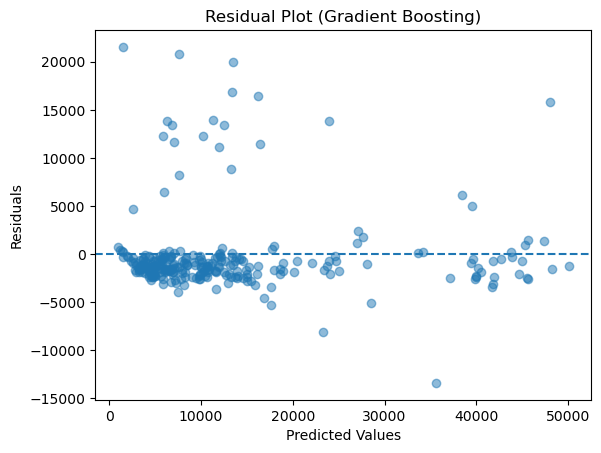

In [17]:
residuals = y_test - best_preds

plt.figure()
plt.scatter(best_preds, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot ({best_name})")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()


### Feature Importance

In this section, we analyze which features have the greatest impact on the predictions made by the **best-performing model**.

- For linear models, feature importance is determined using **coefficients (`coef_`)**.
- For tree-based models, feature importance is determined using **feature importance scores (`feature_importances_`)**.
- Higher values indicate a stronger influence on predicted insurance charges.

The features are sorted in descending order to highlight the most influential variables in the model.

In [30]:
print("\n--- FEATURE IMPORTANCE ---")

if hasattr(best_model, "coef_"):
    # Linear models
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Impact": best_model.coef_
    }).sort_values(by="Impact", ascending=False)

elif hasattr(best_model, "feature_importances_"):
    # Tree-based models
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Impact": best_model.feature_importances_
    }).sort_values(by="Impact", ascending=False)

else:
    feature_importance = None
    print("Feature importance not available for this model.")

if feature_importance is not None:
    print(feature_importance)


--- FEATURE IMPORTANCE ---
                Feature    Impact
4            smoker_yes  0.676070
1                   bmi  0.189838
0                   age  0.117147
2              children  0.009971
5      region_northwest  0.002475
7      region_southwest  0.001383
8    age_group_(30, 45]  0.001308
6      region_southeast  0.000572
3              sex_male  0.000572
10  age_group_(60, 100]  0.000413
9    age_group_(45, 60]  0.000250


### Premium Calculation

In this section, we convert the model’s predicted medical costs into an insurance premium.

Steps:
- The model first predicts the expected medical cost for each individual.
- We then apply additional loadings to account for business considerations:
  - **Risk Margin (15%)**: accounts for uncertainty and potential higher-than-expected claims.
  - **Administrative Load (10%)**: covers operational and business expenses.

The final premium is calculated as:

$$
Premium = Predicted\ Cost \times (1 + Risk\ Margin + Admin\ Load)
$$

This approach reflects a simplified actuarial pricing model used in insurance.

In [26]:
risk_margin = 0.15
admin_load = 0.10

# Predict using BEST model on full dataset
df_encoded["predicted_cost"] = best_model.predict(X)

# Premium calculation (cost + loadings)
df_encoded["premium"] = df_encoded["predicted_cost"] * (1 + risk_margin + admin_load)

### Protfolio Analysis

In this section, we analyze the model’s predicted insurance costs across key demographic groups.

We evaluate:
- **Smoking status**: comparing average predicted costs for smokers and non-smokers.
- **Age groups**: comparing average predicted costs across different age ranges.

Age is divided into the following groups:
- 18–30
- 31–45
- 46–60
- 60–100

This helps verify whether the model reflects expected real-world trends, such as higher costs for smokers and older individuals.

In [23]:
print("\n--- By Smoker Status ---")
print(df_encoded.groupby("smoker_yes")["predicted_cost"].mean())

print("\n--- By Age Group ---")
print(df_encoded.groupby(pd.cut(df_encoded["age"], bins=[17, 30, 45, 60, 100]), observed=True)["predicted_cost"].mean())



--- By Smoker Status ---
smoker_yes
False     8517.525505
True     31977.043270
Name: predicted_cost, dtype: float64

--- By Age Group ---
age
(17, 30]      9412.421010
(30, 45]     12773.586061
(45, 60]     16389.422104
(60, 100]    20979.950728
Name: predicted_cost, dtype: float64


### Loss Ratio

In this section, we evaluate the profitability of the insurance portfolio using the loss ratio.

The **loss ratio** is calculated as:

$
\text{Loss Ratio} = \frac{\text{Total Claims}}{\text{Total Premiums}}
$

Where:
- **Total Claims** = Sum of actual insurance charges
- **Total Premiums** = Sum of predicted premiums from the pricing model

Interpretation:
- Loss Ratio < 1 → Profitable portfolio (premiums exceed claims)
- Loss Ratio ≥ 1 → Unprofitable portfolio (claims exceed premiums)

This is a key metric used in actuarial science to assess pricing adequacy.

In [27]:
total_claims = df_encoded["charges"].sum()
total_premiums = df_encoded["premium"].sum()

loss_ratio = total_claims / total_premiums

print("\n--- LOSS RATIO ---")
print(f"Claims: ${total_claims:,.2f}")
print(f"Premiums: ${total_premiums:,.2f}")
print(f"Loss Ratio: {loss_ratio:.2f}")

if loss_ratio < 1:
    print("Profitable portfolio")
else:
    print("Unprofitable portfolio")



--- LOSS RATIO ---
Claims: $17,755,824.99
Premiums: $22,280,446.24
Loss Ratio: 0.80
Profitable portfolio


### Actuarial Input Tool

#### BMI Calculator (User Input)

In this section, we calculate the Body Mass Index (BMI) using user-provided inputs.

BMI is computed using the formula:

$
\text{BMI} = \frac{\text{Weight (lbs)} \times 703}{\text{Height (inches)}^2}
$

Steps:
- The user inputs weight in pounds and height in feet and inches.
- Height is converted into total inches.
- BMI is calculated and displayed to the user.

This provides a basic health indicator used later as an important risk factor in insurance pricing.

In [32]:
# BMI Calculator with user input

weight_lbs = float(input("Enter your weight (in pounds): "))
height_feet = int(input("Enter your height - feet part: "))
height_inches = int(input("Enter your height - inches part: "))

# Convert height to total inches
total_inches = (height_feet * 12) + height_inches

# Calculate BMI
weight_kg = weight_lbs * 0.453592
height_m = total_inches * 0.0254

bmi = weight_kg / (height_m ** 2)

print(f"Your BMI is: {bmi:.2f}")

Enter your weight (in pounds):  125
Enter your height - feet part:  5
Enter your height - inches part:  4


Your BMI is: 21.46


#### Insurance Cost Prediction System

In this section, we build a simple interactive prediction system that estimates insurance costs based on user input.


#### Steps:
- The user provides personal and health-related information (age, sex, BMI, children, smoker status, region).
- The input is transformed to match the model’s encoded feature format.
- The trained Linear Regression model predicts the expected medical cost.
- A final insurance premium is calculated by adding:
  - Risk margin
  - Administrative load


#### Additional Outputs:
- Classify risk level (Low, Medium, High) based on predicted cost
- Identify the most influential feature from the model


#### Purpose

This simulates a basic actuarial pricing tool used in insurance underwriting by combining machine learning predictions with real-world pricing logic.

In [33]:
# =========================
# USER INPUT
# =========================
age = int(input("Age: "))
sex = input("Sex (male/female): ").strip().lower()
bmi = float(input("BMI: "))
children = int(input("Children: "))
smoker = input("Smoker (yes/no): ").strip().lower()
region = input("Region (northeast/northwest/southeast/southwest): ").strip().lower()

# =========================
# BUILD INPUT DATA
# =========================
input_data = {
    "age": age,
    "bmi": bmi,
    "children": children,
    "bmi_smoker": bmi * (1 if smoker == "yes" else 0),
    "sex_male": 1 if sex == "male" else 0,
    "smoker_yes": 1 if smoker == "yes" else 0,
    "region_northwest": 1 if region == "northwest" else 0,
    "region_southeast": 1 if region == "southeast" else 0,
    "region_southwest": 1 if region == "southwest" else 0,
}

input_df = pd.DataFrame([input_data])

# Align with training columns
input_df = input_df.reindex(columns=X.columns, fill_value=0)

# =========================
# PREDICTION (BEST MODEL)
# =========================
predicted_cost = best_model.predict(input_df)[0]

# =========================
# RISK CLASSIFICATION
# =========================
if predicted_cost < 5000:
    risk_label = "LOW RISK"
    risk_margin = 0.10
elif predicted_cost < 15000:
    risk_label = "MEDIUM RISK"
    risk_margin = 0.15
else:
    risk_label = "HIGH RISK"
    risk_margin = 0.25

admin_load = 0.10

# Premium calculation (risk-based)
premium = predicted_cost * (1 + risk_margin + admin_load)

# =========================
# MONTHLY PAYMENTS
# =========================
monthly_no_interest = premium / 12

# =========================
# TOP DRIVER (SAFE)
# =========================
if 'feature_importance' in globals() and feature_importance is not None:
    top_driver = feature_importance.iloc[0]["Feature"]
else:
    top_driver = "N/A"

# =========================
# OUTPUT
# =========================
print("\n----------------------------")
print(f"MODEL USED:      {best_name}")
print(f"PREDICTED COST: ${predicted_cost:,.2f}")
print(f"PREMIUM:        ${premium:,.2f}")
print(f"MONTHLY:        ${monthly_no_interest:,.2f}")
print(f"RISK LEVEL:     {risk_label}")
print(f"TOP DRIVER:     {top_driver}")
print("----------------------------\n")

Age:  22
Sex (male/female):  female
BMI:  21.46
Children:  0
Smoker (yes/no):  no
Region (northeast/northwest/southeast/southwest):  southwest



----------------------------
MODEL USED:      Gradient Boosting
PREDICTED COST: $1,691.95
PREMIUM:        $2,030.34
MONTHLY:        $169.19
RISK LEVEL:     LOW RISK
TOP DRIVER:     smoker_yes
----------------------------



## Project Summary: Insurance Cost Prediction & Pricing Model

This project builds an end-to-end insurance underwriting and pricing system using machine learning and simplified actuarial concepts.


## Objective

The goal of this project is to predict individual medical insurance costs and convert those predictions into insurance premiums using pricing logic that reflects real-world insurance workflows.

A machine learning model is trained using features such as:
- Age  
- Sex  
- BMI  
- Number of children  
- Smoking status  
- Region  

Multiple regression models were evaluated, and the best-performing model was selected based on RMSE.


## Key Components

### 1. Data Exploration (EDA)
- Checked for missing values and dataset structure
- Generated summary statistics using `describe()`
- Analyzed relationships between key variables and insurance charges:
  - Smoking status vs charges
  - Age vs charges
  - Number of children vs charges
- Performed grouped aggregations to identify risk patterns


### 2. Feature Engineering
- Applied one-hot encoding to convert categorical variables into numerical format
- Defined feature matrix (X) and target variable (y)
- Split data into training and testing sets (80/20 split)
- Ensured feature alignment between training and prediction data


### 3. Model Development
- Trained multiple regression models:
  - Linear Regression  
  - Ridge Regression  
  - Lasso Regression  
  - Random Forest Regressor  
  - Gradient Boosting Regressor  
- Evaluated models using:
  - **RMSE** (prediction error)
  - **R² score** (goodness of fit)
- Selected the best model based on lowest RMSE


### 4. Model Evaluation & Selection
- Compared model performance on test data
- Ranked models by RMSE
- Selected the best-performing model for final predictions
- Generated final predictions using the selected model


### 5. Residual Analysis
- Calculated residuals (actual vs predicted values)
- Visualized residual behavior to assess model performance
- Checked for randomness around zero to validate model fit


### 6. Feature Importance / Interpretation
- Extracted feature importance using:
  - Coefficients (`coef_`) for linear models
  - Feature importance scores (`feature_importances_`) for tree-based models
- Identified most influential variables affecting insurance cost
- Smoking status emerged as the strongest predictor of charges


### 7. Actuarial Pricing Model
- Converted predicted medical costs into insurance premiums:

$
\text{Premium} = \text{Predicted Cost} \times (1 + \text{Risk Margin} + \text{Admin Load})
$

- Assumed:
  - Risk Margin = 15%
  - Administrative Load = 10%


### 8. Monthly Payment System
- Converted annual premiums into monthly payments:

$
\text{Monthly Payment} = \frac{\text{Premium}}{12}
$

- Optional adjustment can be applied to simulate financing effects

### 9. Risk Classification
Individuals were grouped into risk tiers based on predicted cost:
- **Low Risk**: < 5,000  
- **Medium Risk**: 5,000 – 15,000  
- **High Risk**: > 15,000  


## Final Insight

This project simulates a real-world actuarial workflow by combining:

- Machine learning-based prediction  
- Model evaluation and selection  
- Residual and feature importance analysis  
- Insurance pricing logic  
- Risk classification and payment structuring  

It demonstrates how data science can be applied to build simplified underwriting and pricing systems similar to those used in the insurance industry.